# SARIMAX Modeling for Onion (FAQ) in Perumbavoor Market

In this notebook, we focus on **time series forecasting of Onion (FAQ variety)** prices in the **Perumbavoor market**.  
We will use the **SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors)** model to capture seasonality, autocorrelation, and potential external features.  

The workflow includes:
1. Loading and preparing the data  
2. Splitting into train, validation, and test sets  
3. Exploratory analysis (stationarity, ACF/PACF)  
4. SARIMAX model fitting and evaluation  
5. Forecasting on the test set

## Data Preparation and Splitting

In this section, we set up the environment, load the onion price dataset, and prepare it for SARIMAX modeling.  

Steps covered:
1. **Import Libraries**: Load core libraries for data handling, plotting, time series analysis, and evaluation.  
2. **Load Data**: Use project-specific utilities to load the commodity price dataset and important feature groups.  
3. **Define Train/Validation/Test Splits**: Assign fixed date ranges to ensure temporal integrity during modeling.  
4. **Apply Thresholds**: Ensure each split has enough data points (train ≥ 100, validation ≥ 10, test ≥ 5).  
5. **Run DataSplitter**: Generate final train, validation, and test DataFrames that will be used throughout the analysis.

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Time series utilities (stationarity tests, ACF/PACF)
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# SARIMAX model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Evaluation metric
from sklearn.metrics import mean_squared_error

# Project utilities (custom scripts for loading & splitting data)
from utils.load_data import load_data
from utils.data_splitter import DataSplitter


# Load the main dataset and grouped feature importance file
df = load_data('data/commodity_prices.csv')
df_grouped = pd.read_csv('data/important_feature_groups.csv')

# Define train/validation/test date ranges
date_dict = {
    'train_start': "2023-06-01", 'train_end': "2025-06-30",
    'valid_start': "2025-07-01", 'valid_end': "2025-07-31",
    'test_start': "2025-08-01", 'test_end': "2025-08-18"
}

# Minimum data thresholds for each split
thresholds = {
    'train': 100,
    'valid': 10,
    'test': 5
}

# Apply DataSplitter to create train, validation, and test sets
splitter = DataSplitter(df, date_dict, thresholds)
train_df, valid_df, test_df = splitter.run()

## Product–Market Selection

Before fitting SARIMAX, we compare product–market pairs by their record counts and effect sizes.  
This helps identify candidates where seasonal patterns are strong enough to justify time series modeling.  

- We first count records per `(Product_Type, Market)` pair in the training data.  
- Then, we merge these counts with precomputed effect sizes from `df_grouped`.  
- Finally, we sort pairs by **Mean Seasonal Effect Size** and **Record Count**.  

From this ranking, we select **Onion (FAQ) in Perumbavoor** because:  
- It has a **high number of records (621 in training)**, ensuring robust modeling.  
- It shows **strong seasonal dependency** (Mean Season Effect Size ≈ 0.44).  
- Since SARIMAX is computationally expensive, focusing on one representative product–market pair provides a clear case study.  

In [3]:
# Count records per product–market pair in training set
pair_counts = (
    train_df
    .groupby(['Product_Type', 'Market'])
    .size()
    .reset_index(name='Record_Count')
)

# Merge with grouped stats (effect sizes and feature importance)
merged = (
    pair_counts
    .merge(df_grouped, on=['Product_Type', 'Market'], how='left')
)

# Sort by seasonal effect size and record count (both descending)
merged_sorted = (
    merged
    .sort_values(by=['Mean_Season_Effect_Size', 'Record_Count'], ascending=[False, False])
    .reset_index(drop=True)
)

# Display top-ranked product–market pairs
merged_sorted.head()

,Product_Type,Market,Record_Count,important_features,Mean_Commodity_Effect_Size,Mean_Variety_Type_Effect_Size,Mean_Season_Effect_Size,Mean_Market_Effect_Size,Mean_Year_Effect_Size,Total_Records
0,Papaya|Other|Large,Mazhuvannur VFPCK,523,Season|Market|Year,0.039104,0.000000,0.544504,0.177046,0.413011,550.0
1,Orange|Other|Large,Piravam,117,Season,0.000000,0.000000,0.534722,0.000000,0.000000,149.0
2,Onion|Onion|FAQ,Perumbavoor,621,Commodity|Season|Year,0.203802,0.000000,0.439061,0.000000,0.092896,661.0
3,Mango|Other|Large,Piravam,149,Season|Year,0.018415,0.018415,0.431203,0.000000,0.053818,181.0
4,Drumstick|Drumstick|FAQ,Perumbavoor,611,Season,0.001346,0.000000,0.429083,0.025719,0.026158,651.0


## Filtering for Onion (FAQ) in Perumbavoor

We now isolate the chosen product–market pair (**Onion|Onion|FAQ in Perumbavoor**) from the validation and test sets.  
This ensures that all subsequent SARIMAX modeling and evaluation focus only on this series.  

- Validation set size: **26 records** → sufficient for tuning and short-term forecasting checks.  
- Test set size: **14 records** → enough to evaluate out-of-sample performance.  

These sample sizes are reasonable for assessing model performance while keeping the experiment computationally feasible.

In [4]:
# Filter validation and test sets for Onion (FAQ) in Perumbavoor
pair_val_df = valid_df[
    (valid_df['Product_Type'] == 'Onion|Onion|FAQ') &
    (valid_df['Market'] == 'Perumbavoor')
]

pair_test_df = test_df[
    (test_df['Product_Type'] == 'Onion|Onion|FAQ') &
    (test_df['Market'] == 'Perumbavoor')
]

# Check validation and test set sizes
pair_val_df.shape, pair_test_df.shape

((26, 9), (14, 9))

## Extract Training Series

From the training set, we extract the **Onion (FAQ) in Perumbavoor** series.  
Steps:  
- Filter training data for the selected product–market pair.  
- Use `Arrival_Date` as the time index.  
- Select the target variable `log_Modal_Price` (log-transformed modal price).  
- Convert to a **daily frequency (`asfreq('D')`)** to ensure a consistent time index for SARIMAX modeling.  

In [5]:
# Filter training set for Onion (FAQ) in Perumbavoor
pair_df = train_df[
    (train_df['Product_Type'] == 'Onion|Onion|FAQ') &
    (train_df['Market'] == 'Perumbavoor')
]

# Set Arrival_Date as time index and extract log-transformed modal price
# Force daily frequency to standardize the time series
series = pair_df.set_index('Arrival_Date')['log_Modal_Price'].asfreq('D')

series.head()

Arrival_Date
2023-06-01    7.496097
2023-06-02    7.496097
2023-06-03    7.496097
2023-06-04         NaN
2023-06-05    7.496097
Freq: D, Name: log_Modal_Price, dtype: float64

## Visualize Training Series

We now plot the **log-transformed daily modal price** for Onion (FAQ) in Perumbavoor.  
This visualization helps us:  
- Inspect overall trends and seasonal fluctuations.  
- Identify potential structural breaks or anomalies.  
- Confirm that the series is correctly aligned on a daily frequency.  


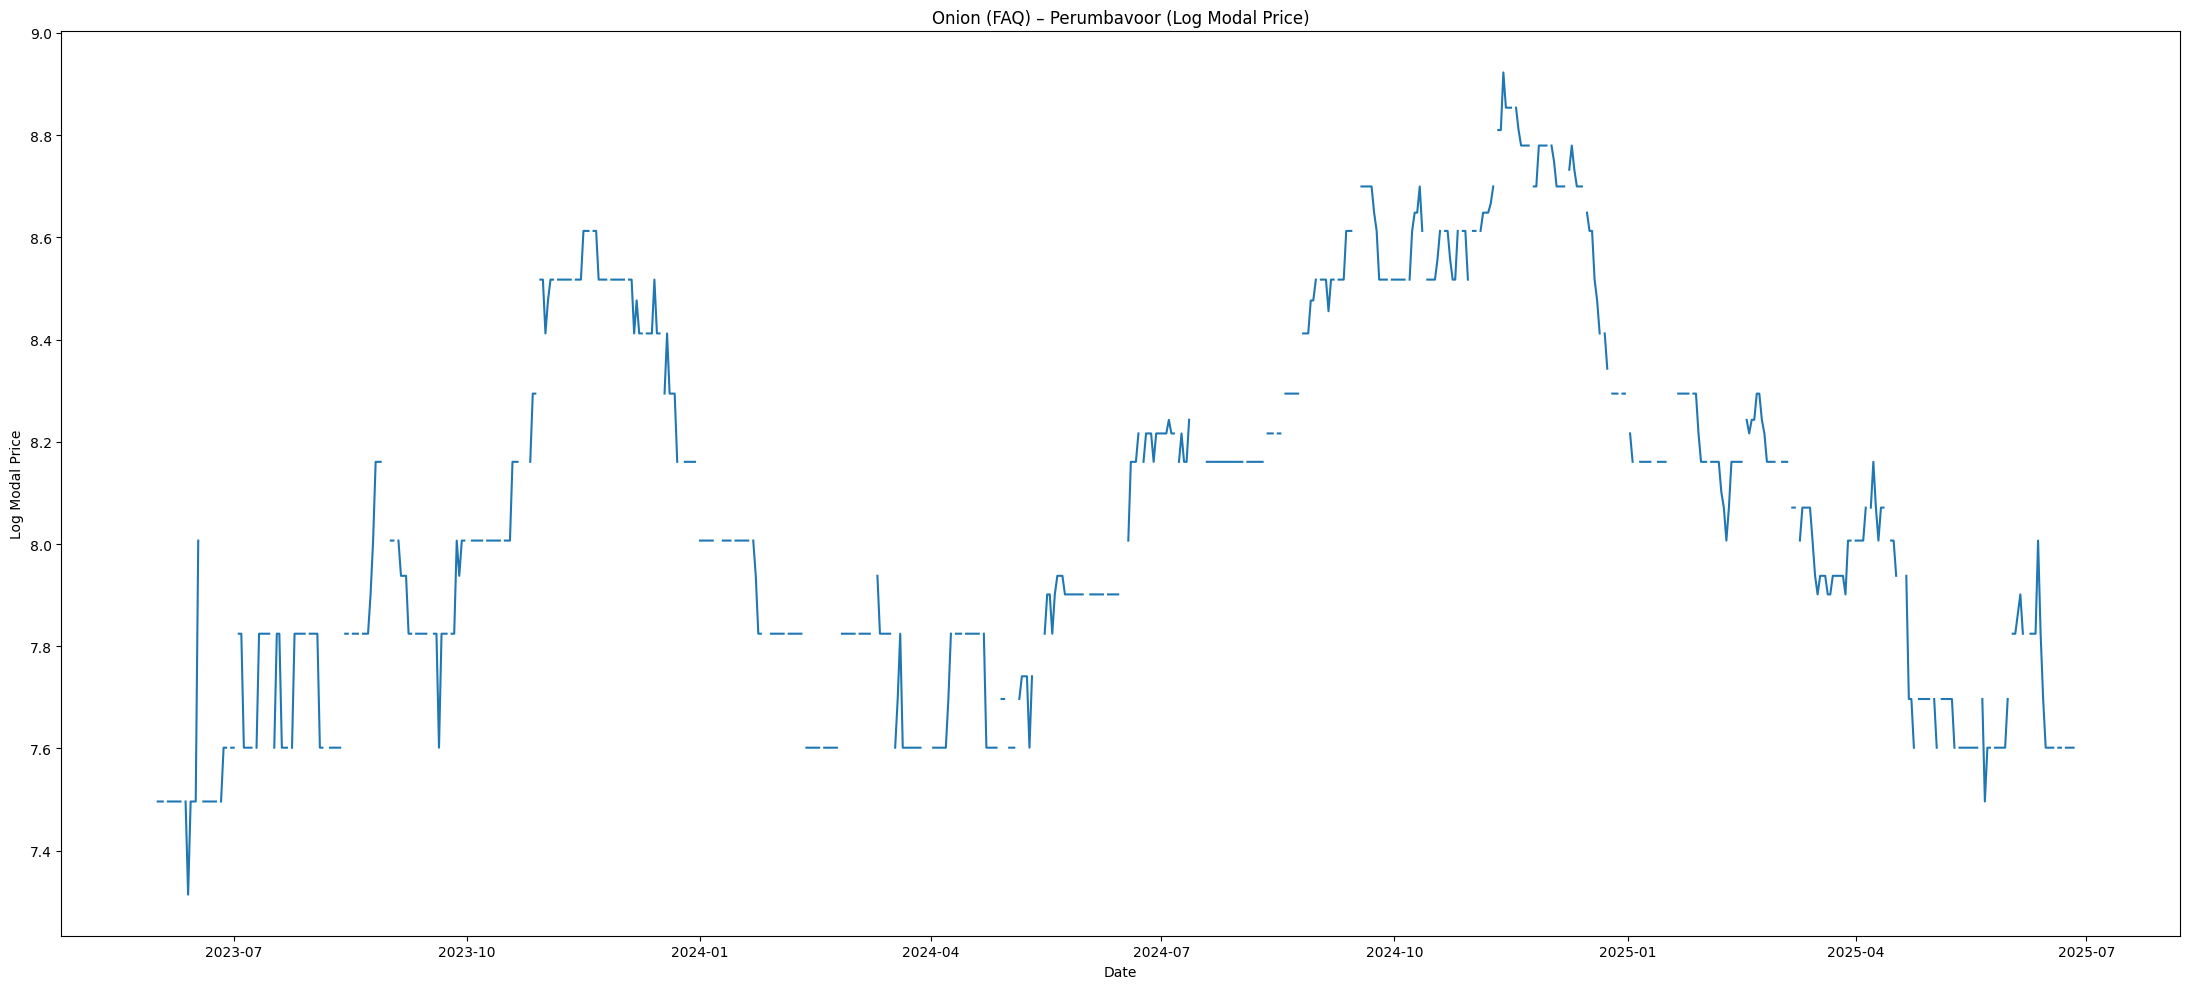

In [ ]:
plt.figure(figsize=(22, 10))
plt.plot(series, color="tab:blue")

# Add titles and labels
plt.title("Onion (FAQ) – Perumbavoor (Log Modal Price)")
plt.ylabel("Log Modal Price")
plt.xlabel("Date")

# Adjust layout
plt.tight_layout()

# Save figure in the 'figures' folder
plt.savefig("figures/onion_perumbavoor_series.png", dpi=300)

# Display plot
plt.show()

## Handle Missing Values in the Series

The raw daily series may contain gaps due to missing arrival dates or reporting issues.  
To make the series continuous for rolling statistics and stationarity testing, we fill missing values as follows:  

- **Forward fill (`ffill`)** with a limit of 3 days: short gaps are carried forward from the last observed value.  
- **Linear interpolation**: remaining gaps are filled smoothly to avoid flat stretches.  

This ensures the series is suitable for computing rolling means/standard deviations and for stationarity tests like ADF and KPSS.

In [ ]:
# Fill short gaps (up to 3 days) using forward fill, then apply linear interpolation
series_filled = series.ffill(limit=3).interpolate(method='linear')

## Rolling Mean and Standard Deviation

To visually assess **stationarity**, we compute and plot the 90-day rolling mean and standard deviation of the log price series.  

- A **stationary series** should have roughly constant mean and variance over time.  
- Significant drifts or changes in the rolling statistics indicate potential non-stationarity, which SARIMAX needs to account for via differencing.  

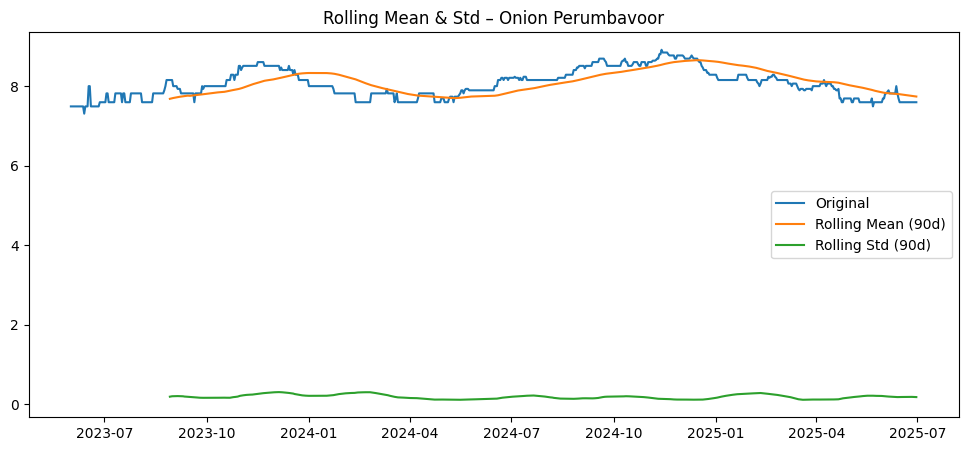

In [ ]:
# Compute 90-day rolling mean and standard deviation
roll_mean = series_filled.rolling(90).mean()
roll_std = series_filled.rolling(90).std()

# Plot the original series with rolling statistics
plt.figure(figsize=(12, 5))
plt.plot(series_filled, label="Original", color="tab:blue")
plt.plot(roll_mean, label="Rolling Mean (90d)", color="tab:orange")
plt.plot(roll_std, label="Rolling Std (90d)", color="tab:green")

plt.legend()
plt.title("Rolling Mean & Std – Onion (FAQ) Perumbavoor (Log Price)")
plt.xlabel("Date")
plt.ylabel("Log Modal Price")
plt.tight_layout()

# Save figure for reference
plt.savefig("figures/onion_perumbavoor_rolling_stats.png", dpi=300)

# Display plot
plt.show()

## Stationarity Tests: ADF & KPSS

To formally test for stationarity, we apply two complementary tests:  

- **Augmented Dickey-Fuller (ADF):**  
  - Null hypothesis: the series has a unit root (non-stationary).  
  - A small p-value (< 0.05) → reject null → evidence of stationarity.  

- **Kwiatkowski-Phillips-Schmidt-Shin (KPSS):**  
  - Null hypothesis: the series is stationary.  
  - A small p-value (< 0.05) → reject null → evidence of non-stationarity.  

By using both, we get a more reliable view. If they disagree, the series is likely “trend stationary” rather than strictly stationary.  

In [ ]:
# ADF test helper
def adf_test(series):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")

# KPSS test helper
def kpss_test(series):
    result = kpss(series.dropna(), regression='c', nlags="auto")
    print(f"KPSS Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")

# Run both tests on the filled series
print("Original series (log price, filled):")
adf_test(series_filled)
kpss_test(series_filled)

Original series:
ADF Statistic: -1.6149, p-value: 0.4754
KPSS Statistic: 0.6396, p-value: 0.0190


### Stationarity Tests – Onion (FAQ) Perumbavoor

- **ADF Test:**  
  - Result: ADF statistic = `-2.35`, p-value = `0.155` → Fail to reject null.  
  - Interpretation: Series appears **non-stationary** by ADF.  

- **KPSS Test:** 
  - Result: KPSS statistic = `0.92`, p-value = `0.027` → Reject null.  
  - Interpretation: Series appears **non-stationary** by KPSS.  

**Conclusion:** Both tests indicate the series is **non-stationary**, suggesting transformations (e.g., differencing, log transform, seasonal adjustments) are needed before modeling.  

## First Differencing to Remove Trend

Since the original series was non-stationary, we apply **first differencing** to remove the trend:  

- `diff1 = series_filled.diff().dropna()` computes the difference between consecutive days.  
- We then re-run **ADF** and **KPSS** tests to verify stationarity.  

**Results after first differencing:**  
- **ADF Statistic:** -6.9745, p-value ≈ 0.000 → Reject null → **Stationary**  
- **KPSS Statistic:** 0.2154, p-value ≈ 0.10 → Fail to reject null → **Stationary**  

**Conclusion:** The series is now stationary, suitable for SARIMAX modeling.  
> ⚠️ Note: KPSS issued a minor `InterpolationWarning`, which does not affect interpretation here.  

In [ ]:
# Apply first differencing to remove trend
diff1 = series_filled.diff().dropna()
print("Series with trend removed for 1 lag")

# Run stationarity tests on differenced series
adf_test(diff1)
kpss_test(diff1)

Series with tren removed for 1 lag
ADF Statistic: -6.9745, p-value: 0.0000
KPSS Statistic: 0.2154, p-value: 0.1000


/var/folders/x4/b7s9rw593ls2crh0j05hx9qr0000gn/T/ipykernel_52317/462064618.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags="auto")


## Seasonal Differencing

To account for **annual seasonality**, we apply **seasonal differencing** with a lag of 365 days:  

- `y_seasonal_diff = series_filled.diff(365).dropna()` removes recurring seasonal patterns.  
- We plot both the **seasonally differenced series** and the **original series** for comparison.  
- This helps visually assess whether the seasonality has been removed, preparing the series for SARIMAX modeling.  

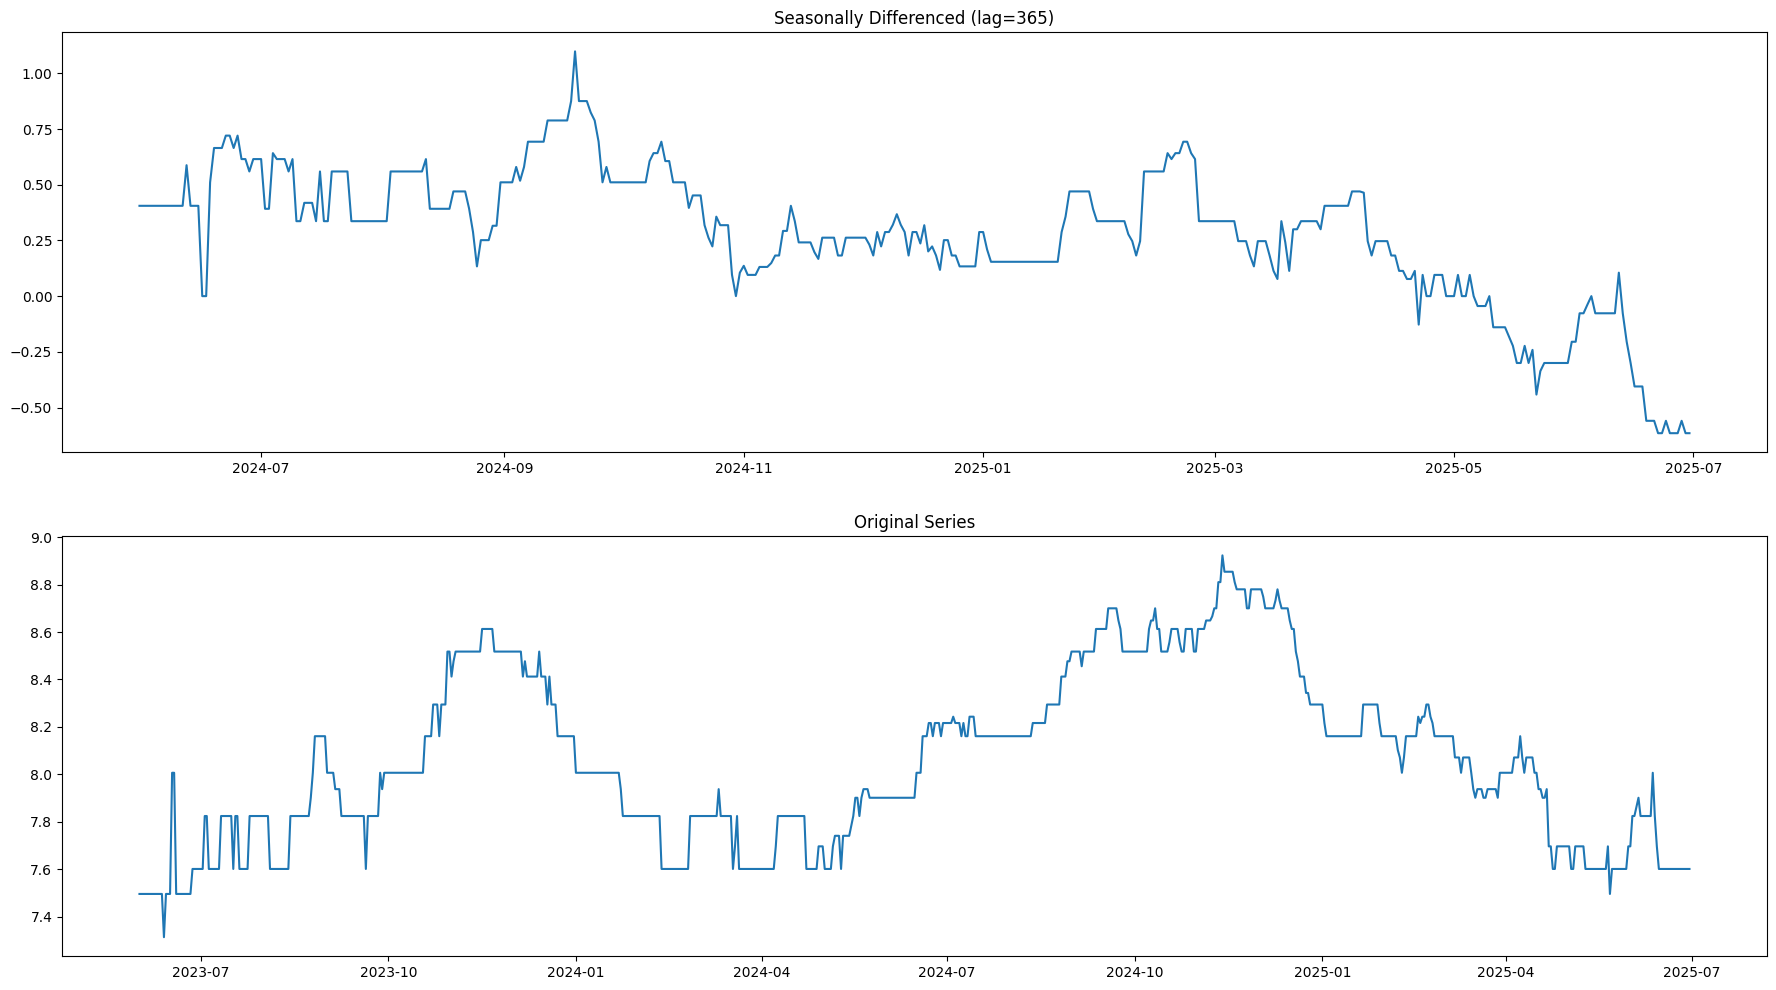

In [ ]:
# Apply seasonal differencing with lag=365
y_seasonal_diff = series_filled.diff(365).dropna()

# Plot seasonally differenced vs. original series
fig, axes = plt.subplots(2, figsize=(22, 12))

axes[0].plot(y_seasonal_diff, color="tab:orange")
axes[0].set_title("Seasonally Differenced Series (lag=365)")

axes[1].plot(series_filled, color="tab:blue")
axes[1].set_title("Original Series")

plt.tight_layout()

# Save figure to figures folder
plt.savefig("figures/onion_perumbavoor_seasonal_diff.png", dpi=300)

# Display plot
plt.show()

### Seasonal Differencing – Trend and Seasonality Removed

After applying **seasonal differencing (lag=365)**:  

- The **long-term trend** and **annual seasonal patterns** in the Onion (FAQ) series for Perumbavoor are largely removed.  
- The resulting series is more **stationary**, making it suitable for SARIMAX modeling.  
- This step ensures the model can focus on short-term fluctuations without being influenced by trend or seasonality.  

## Autocorrelation and Partial Autocorrelation

To identify the appropriate SARIMAX parameters (`p`, `q`, `P`, `Q`), we examine **autocorrelation (ACF)** and **partial autocorrelation (PACF)** plots after both **seasonal and first differencing**:  

- `y_diff = y_seasonal_diff.diff().dropna()` removes remaining trend after seasonal differencing.  
- We plot **short-term lags** (up to ~2 months) and **long-term lags** (up to 1 year) to capture daily and seasonal autocorrelations.  
- These plots help in deciding the AR (autoregressive) and MA (moving average) orders for both seasonal and non-seasonal components.  

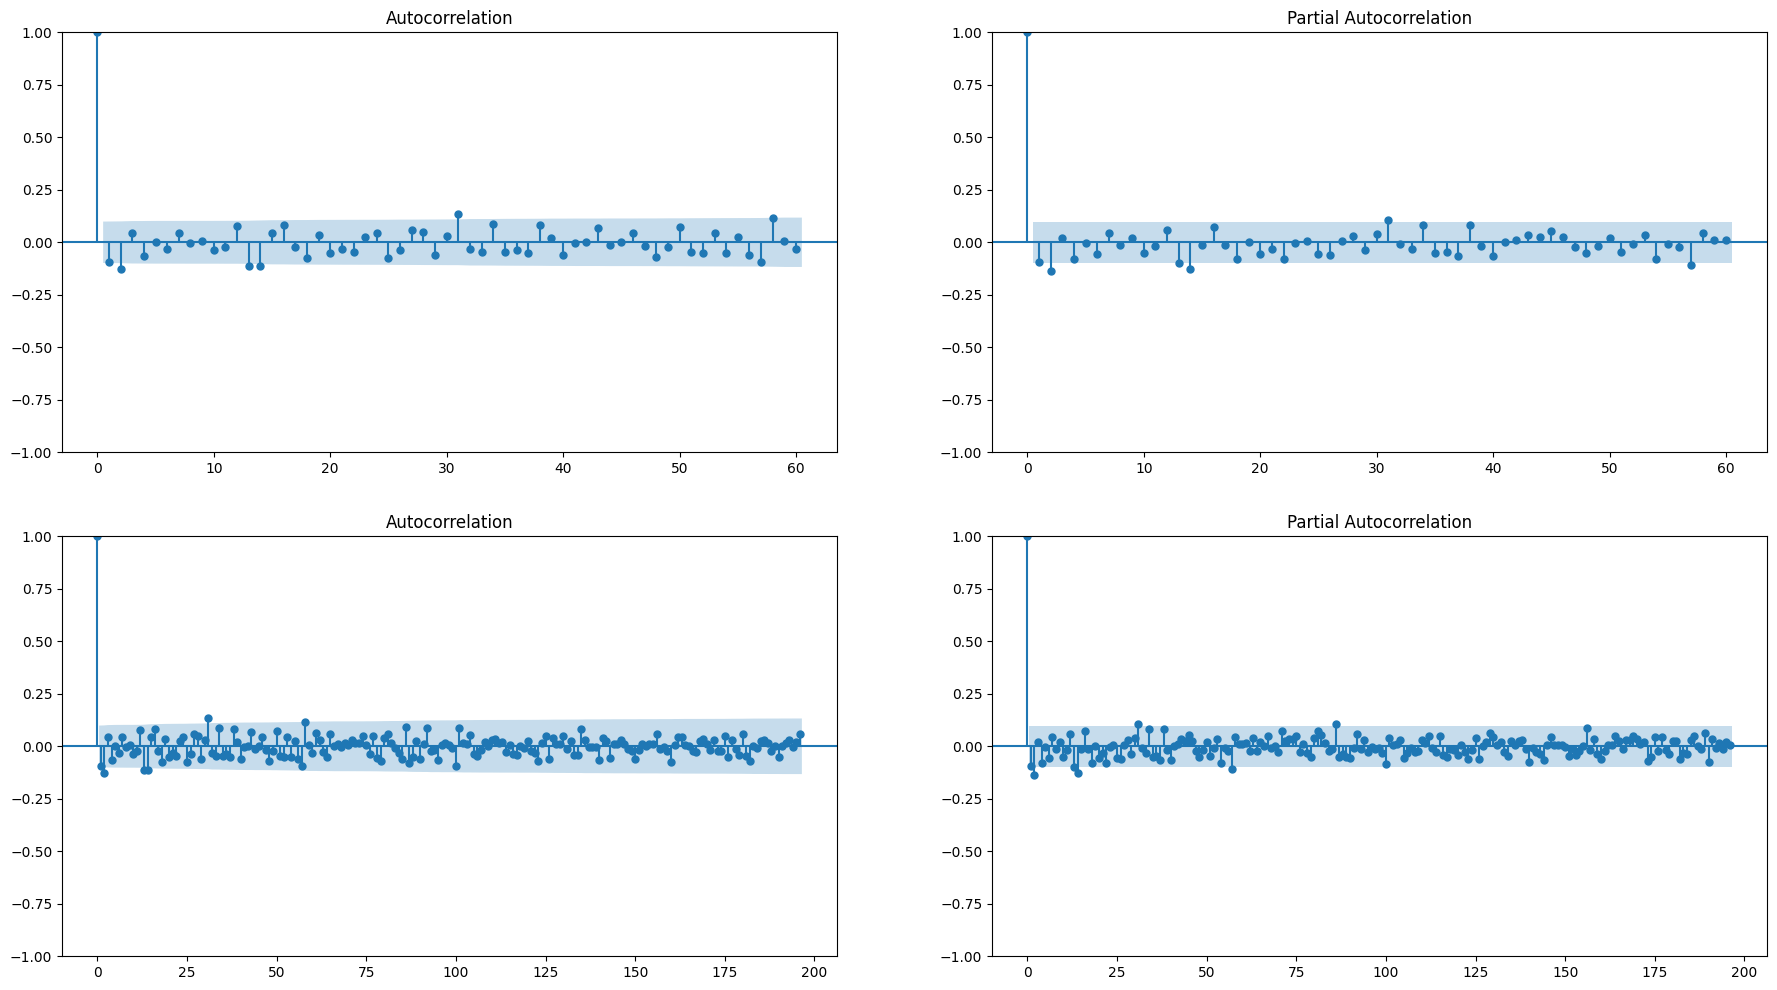

In [ ]:
# Series after seasonal + first differencing
y_diff = y_seasonal_diff.diff().dropna()

# Determine lag lengths for short-term and long-term patterns
nlags_short = min(60, len(y_diff)//2 - 1)    # ~days to 2 months
nlags_long  = min(365, len(y_diff)//2 - 1)   # ~1 year

# Plot ACF and PACF
fig, axes = plt.subplots(2, 2, figsize=(22, 12))
axes = axes.flatten()

plot_acf(y_diff, lags=nlags_short, ax=axes[0])
axes[0].set_title("ACF – Short-term Lags")
plot_pacf(y_diff, lags=nlags_short, ax=axes[1])
axes[1].set_title("PACF – Short-term Lags")

plot_acf(y_diff, lags=nlags_long, ax=axes[2])
axes[2].set_title("ACF – Long-term Lags")
plot_pacf(y_diff, lags=nlags_long, ax=axes[3])
axes[3].set_title("PACF – Long-term Lags")

plt.tight_layout()

# Save figure to figures folder
plt.savefig("figures/onion_perumbavoor_ACF_PACF.png", dpi=300)

# Display plots
plt.show()

## SARIMA Model Selection – Onion (FAQ) Perumbavoor

Based on the series diagnostics (plots, rolling statistics, ADF/KPSS tests, ACF/PACF), we selected a **SARIMA(2,1,2)(0,1,0)[365]** model.  

**Rationale:**

- **d = 1** – The original series was non-stationary (ADF/KPSS tests and rolling mean). One non-seasonal difference removes the trend.  
- **D = 1, s = 365** – Clear yearly seasonality observed; seasonal differencing by 365 days removes the annual cycle.  
- **p = 2** – PACF after differencing shows significant spikes at lag 1 and 2, indicating short-term dependence (non-seasonal AR(2)).  
- **q = 2** – ACF after differencing shows significant spikes at lag 1 and 2, capturing short-lived shocks (non-seasonal MA(2)).  
- **P = 0, Q = 0** – No clear isolated spikes at the seasonal lag in ACF/PACF; the seasonal pattern is already handled by seasonal differencing.  

> This slightly more flexible model captures both short-term autocorrelations and yearly seasonality while remaining parsimonious. Seasonal AR/MA terms beyond differencing can be added later if diagnostics suggest it.

## Fit SARIMAX Model

We fit the SARIMAX model on the **log-transformed, filled daily series** for Onion (FAQ) in Perumbavoor using the selected parameters:  

- **order=(2,1,2):** non-seasonal AR(2), one difference (d=1), non-seasonal MA(2)  
- **seasonal_order=(0,1,0,365):** seasonal differencing by 365 days, no seasonal AR/MA terms  
- **enforce_stationarity=False, enforce_invertibility=False:** allow the model to fit even if roots are near the non-stationary/invertible boundaries  

The `fit()` method estimates model parameters using maximum likelihood, and `result.summary()` displays:  
- Estimated coefficients for AR and MA terms  
- Standard errors and significance levels  
- Model diagnostics including AIC/BIC for model comparison  

In [ ]:
# Initialize and fit SARIMAX model
model = SARIMAX(
    series_filled,
    order=(2, 1, 2),
    seasonal_order=(0, 1, 0, 365),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit the model and inspect summary
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                      log_Modal_Price   No. Observations:                  761
Model:             SARIMAX(2, 1, 2)x(0, 1, [], 365)   Log Likelihood                 429.316
Date:                              Sun, 07 Sep 2025   AIC                           -848.633
Time:                                      18:18:36   BIC                           -828.777
Sample:                                  06-01-2023   HQIC                          -840.763
                                       - 06-30-2025                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3840      0.202     -1.897      0.058      -0.781       0.013
ar.L2          0.2415      0.237      1.019      0.308      -0.223       0.706
ma.L1          0.2878      0.196      1.470      0.142      -0.096       0.672
ma.L2         -0.4300      0.228     -1.882      0.060      -0.878       0.018
sigma2         0.0066      0.000     21.943      0.000       0.006       0.007
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               492.64
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               0.59   Skew:                             0.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## SARIMAX Model Diagnostics

After fitting the SARIMAX model, we use `result.plot_diagnostics()` to evaluate model assumptions and fit quality.  

The diagnostic plots include:  
- Standardized residuals (to check for bias or heteroscedasticity)  
- Histogram + KDE of residuals (to check normality)  
- Normal Q-Q plot (to assess residual normality)  
- Correlogram (ACF of residuals to detect remaining autocorrelation)  

These plots help verify that the residuals behave like **white noise**, indicating a good model fit.  

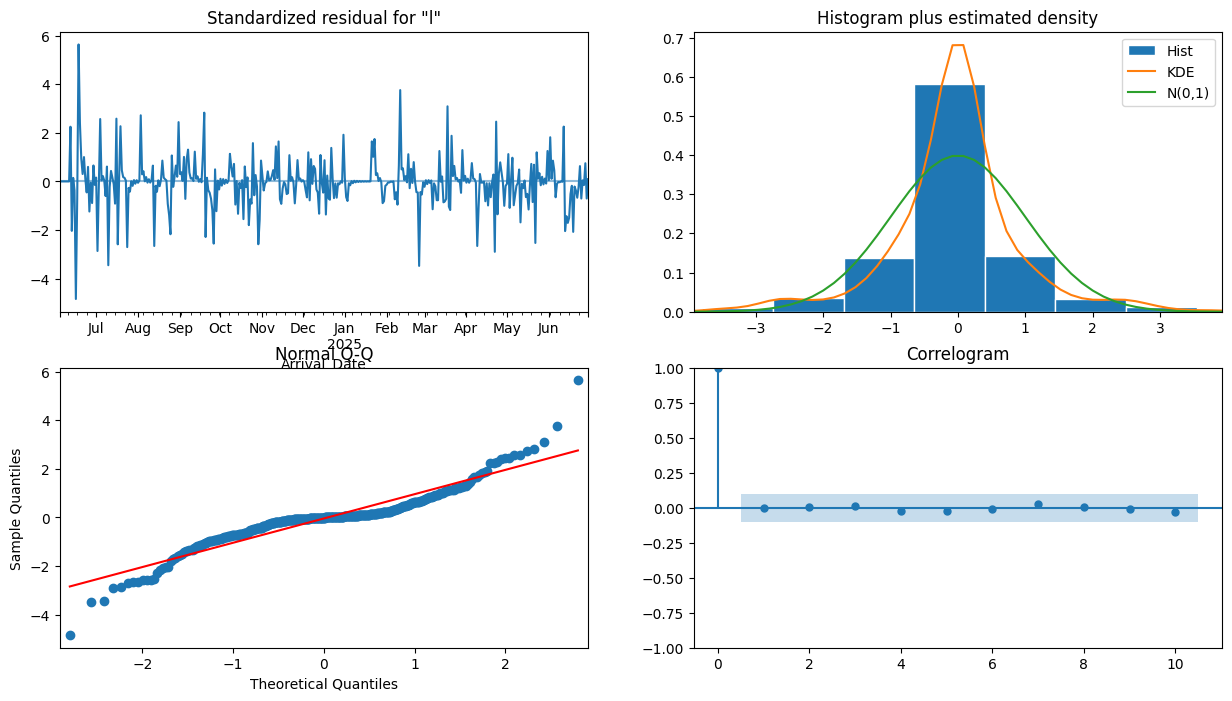

In [ ]:
# Plot SARIMAX diagnostics
fig = result.plot_diagnostics(figsize=(15, 8))

# Save the diagnostics figure
fig.savefig("figures/onion_perumbavoor_SARIMAX_diagnostics.png", dpi=300)

plt.show()

In [23]:
valid = pair_val_df.set_index('Arrival_Date')['log_Modal_Price']
forecast_res = result.get_prediction(start='01/07/2025', end='31/07/2025')
forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

# --- Align forecast with sparse validation ---
common_idx = valid.index.intersection(forecast_mean.index)
y_true = valid.loc[common_idx]
y_pred = forecast_mean.loc[common_idx]
conf_match = conf_int.loc[common_idx]

# --- Metrics ---
rmse = np.sqrt(mean_squared_error(y_true.values, y_pred.values))
mape = np.mean(np.abs((y_true.values - y_pred.values) / y_true.values)) * 100

print("Model Fit Summary")
print("-" * 40)

print(f"AIC : {result.aic:.2f}")
print(f"BIC : {result.bic:.2f}\n")

print("Validation Metrics (on available dates only)")
print("-" * 40)
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%\n")


Model Fit Summary
----------------------------------------
AIC : -848.63
BIC : -828.78

Validation Metrics (on available dates only)
----------------------------------------
RMSE : 0.27
MAPE : 3.31%



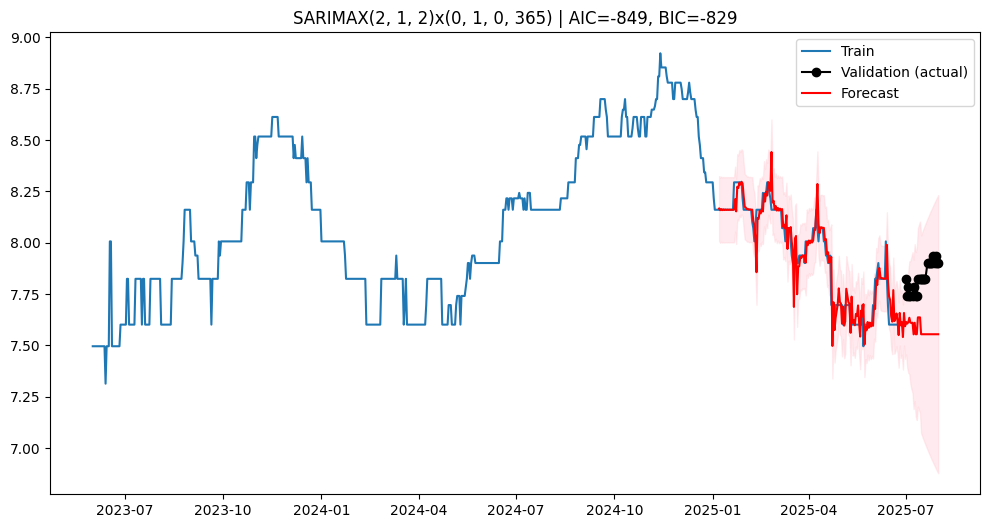

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(series_filled.index, series_filled, label="Train")
plt.plot(y_true.index, y_true, "o-", label="Validation (actual)", color="black")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", color="red")
plt.fill_between(forecast_mean.index,
                    conf_int.iloc[:, 0],
                    conf_int.iloc[:, 1], color="pink", alpha=0.3)
plt.legend()
plt.title(f"SARIMAX{2, 1, 2}x{0, 1, 0, 365} | AIC={result.aic:.0f}, BIC={result.bic:.0f}")
plt.show()
